# 🛡️ Módulo 01: Machine Learning Estadístico & Optimización Convexa
## Capítulo 2: La Geometría de la Regularización (L1 Lasso vs L2 Ridge & Weight Decay)

> *"Regularizar no es aplicar una heurística arbitraria; es restringir la búsqueda en el espacio de parámetros a una región geométrica donde el modelo no puede memorizar ruido estadístico."*

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/mcarbonell/algo-to-ai/blob/main/notebooks/01_classical_ml/02_regularization_geometry.ipynb)

---

### ⚙️ Inicialización del Entorno
Cargamos las librerías necesarias y fijamos semillas para asegurar reproducibilidad.

In [1]:
# !pip install -q numpy matplotlib torch scikit-learn
from typing import Tuple, List
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn

np.random.seed(42)
torch.manual_seed(42)
print("✅ Entorno listo para explorar la geometría de la regularización")

✅ Entorno listo para explorar la geometría de la regularización


---

## 1. 📜 Contexto Histórico y Proceso de Descubrimiento

### La Crisis de la Multicolinealidad en los Años 60: Nace Ridge Regression
En la década de 1960, los ingenieros químicos e industriales se enfrentaron a un problema matemático desconcertante al usar la Ecuación Normal de Mínimos Cuadrados Ordinarios ($w^* = (X^T X)^{-1} X^T y$).

Cuando dos o más variables predictoras estaban correlacionadas (ej. temperatura en dos sensores cercanos), la matriz $X^T X$ se volvía casi singular: sus valores propios más pequeños se aproximaban peligrosamente a cero. Al calcular la inversa $(X^T X)^{-1}$, **los pesos calculados explotaban a magnitudes absurdas** (como $+10.000$ y $-9.999$), y una fluctuación infinitesimal en los datos de entrada destruía por completo las predicciones del modelo.

En 1970, **Arthur Hoerl y Robert Kennard** publicaron un artículo histórico en *Technometrics* introduciendo **Ridge Regression** (Regresión de Cresta):
$$w^*_{Ridge} = (X^T X + \lambda I)^{-1} X^T y$$

Al sumar una pequeña constante positiva $\lambda$ a la diagonal principal, el condicionamiento de la matriz mejoraba drásticamente, garantizando una inversión numéricamente estable y contrayendo la magnitud de los pesos.

### El Problema de las 10.000 Variables y el Momento Eureka de Tibshirani (1996)
Ridge funcionaba de maravilla para estabilizar el modelo, pero tenía una limitación fundamental para la ciencia moderna: **nunca hacía ningún peso exactamente cero**.

En la década de 1990, con la explosión de la bioinformática y la genómica, los investigadores tenían datasets con miles de genes pero apenas unas pocas decenas de pacientes ($d \gg m$). Ridge asignaba un coeficiente diminuto pero no nulo a cada gen, haciendo imposible saber qué genes eran biológicamente relevantes.

En 1996, el estadístico de la Universidad de Toronto **Robert Tibshirani** publicó el paper seminal *"Regression Shrinkage and Selection via the Lasso"* (LASSO: Least Absolute Shrinkage and Selection Operator).

Tibshirani sustituyó la penalización cuadrática $L_2$ ($\sum w_i^2$) por una penalización de valor absoluto $L_1$ ($\sum |w_i|$). El resultado fue asombroso: **Lasso realizaba automáticamente selección de características (*feature selection*)**, apagando las variables irrelevantes poniéndolas a cero exacto.

---

## 2. 🧠 Intuición Geométrica y Mecánica (Mentalidad de Algoritmista)

### ¿Por qué L1 produce Ceros Exactos (Sparsity) y L2 no?
El misterio de por qué la norma $L_1$ apaga pesos y la norma $L_2$ solo los hace pequeños no se entiende con fórmulas secas, sino con **geometría en el espacio de parámetros**.

Podemos formular cualquier problema de regularización como un problema de optimización restringida (Multiplicadores de Lagrange):

$$\min_w \mathcal{L}_{MSE}(w) \quad \text{sujeto a} \quad \|w\|_p \le C$$

* Las curvas de nivel de la función de pérdida $\mathcal{L}_{MSE}(w)$ son **elipses concéntricas** que se expanden hacia afuera desde el punto óptimo no regularizado $w_{OLS}$.
* La región de restricción para **$L_2$ (Ridge)** es una **esfera o disco circular** suave: $w_1^2 + w_2^2 \le C^2$.
* La región de restricción para **$L_1$ (Lasso)** es un **diamante con vértices afilados** sobre los ejes de coordenadas: $|w_1| + |w_2| \le C$.

> **El Momento Eureka Geométrico:** Conforme la elipse de coste se expande desde el centro, ¿dónde choca primero con la región permitida?
> * En $L_2$, el círculo es suave en todas direcciones; casi siempre choca en un punto de tangencia arbitrario donde **ambas coordenadas son distintas de cero**.
> * En $L_1$, el diamante tiene esquinas puntiagudas que sobresalen en los ejes. Con una probabilidad abrumadora, la elipse hace primer contacto en **una de las esquinas sobre el eje**, donde una o más coordenadas son **exactamente $0.0$**.

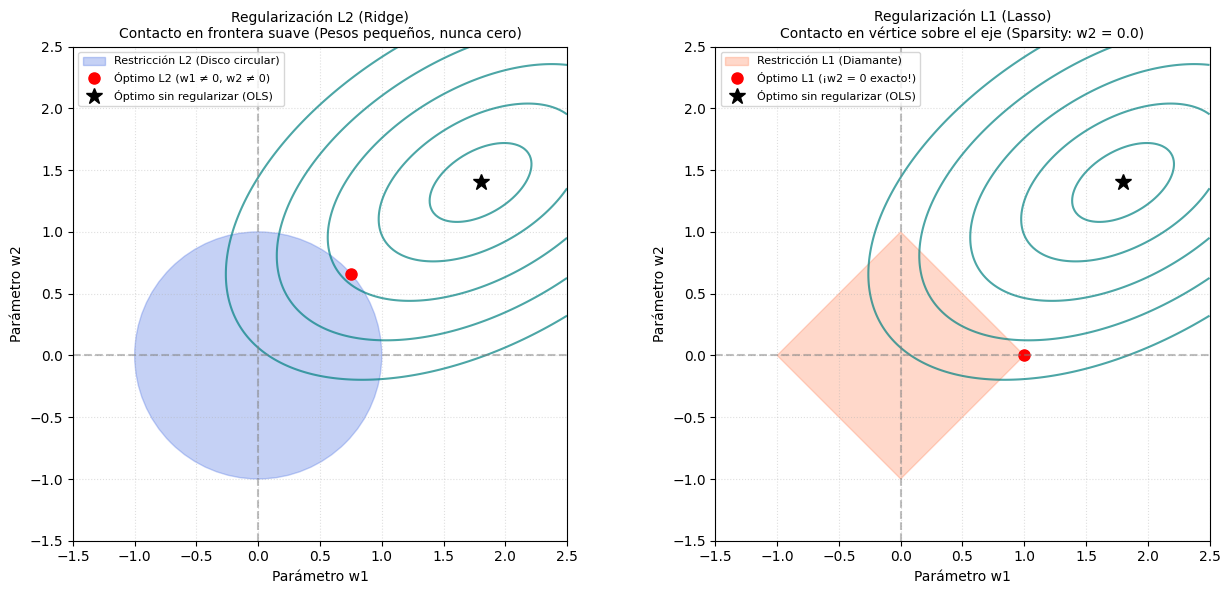

In [2]:
# Visualización de la Geometría de Tibshirani: Esferas suaves (L2) vs Vértices afilados (L1)
fig, (ax_l2, ax_l1) = plt.subplots(1, 2, figsize=(13, 6))

# Óptimo sin regularizar (OLS)
w_ols = np.array([1.8, 1.4])

# Malla 2D para curvas de nivel de pérdida elíptica
w1 = np.linspace(-1.5, 2.5, 200)
w2 = np.linspace(-1.5, 2.5, 200)
W1, W2 = np.meshgrid(w1, w2)
# Elipse inclinada que simula correlación entre variables
Z = 1.5 * (W1 - w_ols[0])**2 + 2.5 * (W2 - w_ols[1])**2 - 1.8 * (W1 - w_ols[0]) * (W2 - w_ols[1])

# 1. Panel L2 (Ridge)
ax_l2.contour(W1, W2, Z, levels=[0.2, 0.8, 1.8, 3.2, 5.0], colors='teal', alpha=0.7)
circle = plt.Circle((0, 0), 1.0, color='royalblue', alpha=0.3, label='Restricción L2 (Disco circular)')
ax_l2.add_patch(circle)
# Punto de contacto L2 (tangente suave)
ax_l2.plot(0.75, 0.66, 'ro', markersize=8, label='Óptimo L2 (w1 ≠ 0, w2 ≠ 0)')
ax_l2.plot(w_ols[0], w_ols[1], 'k*', markersize=12, label='Óptimo sin regularizar (OLS)')
ax_l2.set_title("Regularización L2 (Ridge)\nContacto en frontera suave (Pesos pequeños, nunca cero)", fontsize=10)

# 2. Panel L1 (Lasso)
ax_l1.contour(W1, W2, Z, levels=[0.2, 0.8, 1.8, 3.2, 5.0], colors='teal', alpha=0.7)
# Diamante L1: vertices en (1,0), (0,1), (-1,0), (0,-1)
diamond = plt.Polygon([[1.0, 0], [0, 1.0], [-1.0, 0], [0, -1.0]], color='coral', alpha=0.3, label='Restricción L1 (Diamante)')
ax_l1.add_patch(diamond)
# Punto de contacto L1 (esquina sobre el eje)
ax_l1.plot(1.0, 0.0, 'ro', markersize=8, label='Óptimo L1 (¡w2 = 0 exacto!)')
ax_l1.plot(w_ols[0], w_ols[1], 'k*', markersize=12, label='Óptimo sin regularizar (OLS)')
ax_l1.set_title("Regularización L1 (Lasso)\nContacto en vértice sobre el eje (Sparsity: w2 = 0.0)", fontsize=10)

for ax in (ax_l2, ax_l1):
    ax.axhline(0, color='gray', linestyle='--', alpha=0.5)
    ax.axvline(0, color='gray', linestyle='--', alpha=0.5)
    ax.set_xlim(-1.5, 2.5)
    ax.set_ylim(-1.5, 2.5)
    ax.set_aspect('equal')
    ax.set_xlabel('Parámetro w1')
    ax.set_ylabel('Parámetro w2')
    ax.grid(True, linestyle=':', alpha=0.4)
    ax.legend(loc='upper left', fontsize=8)

plt.tight_layout()
plt.show()

### La Conexión con Deep Learning: Weight Decay
En redes neuronales, el término "regularización $L_2$" se asocia frecuentemente con **Weight Decay** (decaimiento de pesos). ¿Por qué?

Consideremos la función de pérdida con penalización $L_2$:
$$\mathcal{L}_{total}(w) = \mathcal{L}(w) + \frac{\lambda}{2} \|w\|^2_2$$

Calculando el gradiente y aplicando la regla de actualización del descenso de gradiente:
$$w_{t+1} = w_t - \eta \left( \nabla \mathcal{L}(w_t) + \lambda w_t \right)$$
$$w_{t+1} = \mathbf{(1 - \eta \lambda) w_t} - \eta \nabla \mathcal{L}(w_t)$$

> **Intuición Física:** En cada paso de optimización, antes de mover el parámetro en la dirección del gradiente, **multiplicamos el peso actual por un factor de contracción** $(1 - \eta \lambda) < 1$. Si un parámetro no recibe gradientes significativos que justifiquen su existencia, decae exponencialmente hacia cero.

---

## 3. 🛠️ Implementación "From Scratch" (Primeros Principios)

### A. Ridge Regression en Forma Cerrada
$$w^*_{Ridge} = (X^T X + \lambda I)^{-1} X^T y$$
*(Nota: El término de sesgo $b$ nunca debe regularizarse, por lo que $I_{0,0} = 0$).*

In [3]:
class RidgeRegressionFromScratch:
    """
    Regresión Ridge con solución analítica estable en forma cerrada.
    """
    def __init__(self, alpha: float = 1.0):
        self.alpha = float(alpha)  # Parámetro de regularización lambda
        self.weights = None
        self.bias = 0.0

    def fit(self, X: np.ndarray, y: np.ndarray):
        m, d = X.shape
        # Matriz identidad para regularización (d x d)
        I = np.eye(d)
        
        # Centramos X e y para calcular el sesgo analíticamente de forma desacoplada
        X_mean = np.mean(X, axis=0)
        y_mean = np.mean(y)
        X_centered = X - X_mean
        y_centered = y - y_mean
        
        # Resolver (X_c^T @ X_c + alpha * I) @ w = X_c^T @ y_c
        A = X_centered.T @ X_centered + self.alpha * I
        b_vec = X_centered.T @ y_centered
        self.weights = np.linalg.solve(A, b_vec)
        self.bias = y_mean - np.dot(X_mean, self.weights)
        return self

    def predict(self, X: np.ndarray) -> np.ndarray:
        return X @ self.weights + self.bias

print("✅ RidgeRegressionFromScratch definida")

✅ RidgeRegressionFromScratch definida


### B. Lasso Regression mediante Descenso por Coordenadas (Coordinate Descent)

¿Por qué no podemos usar la Ecuación Normal o Descenso de Gradiente simple para Lasso?
Porque la derivada de $|w_j|$ es discontinua en $w_j = 0$ (es $+1$ si $w_j > 0$, $-1$ si $w_j < 0$, e indefinida en cero).

El algoritmo canónico para Lasso es **Coordinate Descent** optimizando una coordenada a la vez mediante el **Operador de Umbral Suave (Soft-Thresholding)**:

$$S(\rho_j, \lambda) = \begin{cases} 
\rho_j - \lambda & \text{si } \rho_j > \lambda \\
0 & \text{si } |\rho_j| \le \lambda \\
\rho_j + \lambda & \text{si } \rho_j < -\lambda 
\end{cases} = \text{sign}(\rho_j) \max(|\rho_j| - \lambda, 0)$$

Donde $\rho_j = X_{:, j}^T (y - \hat{y}_{-j})$ mide la correlación del residuo con la característica $j$.

In [4]:
class LassoRegressionFromScratch:
    """
    Regresión Lasso pura en NumPy mediante Coordinate Descent con Soft-Thresholding.
    """
    def __init__(self, alpha: float = 1.0, max_iter: int = 1000, tol: float = 1e-4):
        self.alpha = float(alpha)
        self.max_iter = max_iter
        self.tol = tol
        self.weights = None
        self.bias = 0.0

    @staticmethod
    def _soft_threshold(rho: float, lam: float) -> float:
        if rho > lam:
            return rho - lam
        elif rho < -lam:
            return rho + lam
        else:
            return 0.0

    def fit(self, X: np.ndarray, y: np.ndarray):
        m, d = X.shape
        # Centrar datos
        X_mean = np.mean(X, axis=0)
        y_mean = np.mean(y)
        X_c = X - X_mean
        y_c = y - y_mean
        
        # Normalizar las normas cuadráticas de cada columna para simplificar cálculo: z_j = ||x_j||^2
        z = np.sum(X_c ** 2, axis=0)
        self.weights = np.zeros(d)
        
        for it in range(self.max_iter):
            w_old = self.weights.copy()
            
            # Bucle de optimización coordenada a coordenada
            for j in range(d):
                if z[j] == 0:
                    continue
                # Residuo parcial sin la contribución de la característica j
                residual_j = y_c - (X_c @ self.weights - X_c[:, j] * self.weights[j])
                rho_j = np.dot(X_c[:, j], residual_j)
                
                # Aplicar el operador de umbral suave
                self.weights[j] = self._soft_threshold(rho_j, self.alpha) / z[j]
                
            # Comprobar convergencia
            if np.max(np.abs(self.weights - w_old)) < self.tol:
                break
                
        self.bias = y_mean - np.dot(X_mean, self.weights)
        return self

    def predict(self, X: np.ndarray) -> np.ndarray:
        return X @ self.weights + self.bias

print("✅ LassoRegressionFromScratch definida")

✅ LassoRegressionFromScratch definida


### Experimento de Selección de Características: 3 Variables Reales y 17 Columnas de Ruido Puro
Vamos a poner a prueba Ridge vs Lasso en un escenario real de ciencia de datos:
* Generamos un dataset de 20 variables ($d=20$).
* **Solo las primeras 3 variables** influyen en $y$ (con pesos $5.0, -3.0, 2.0$).
* Las restantes 17 variables son **ruido gaussiano irrelevante**.

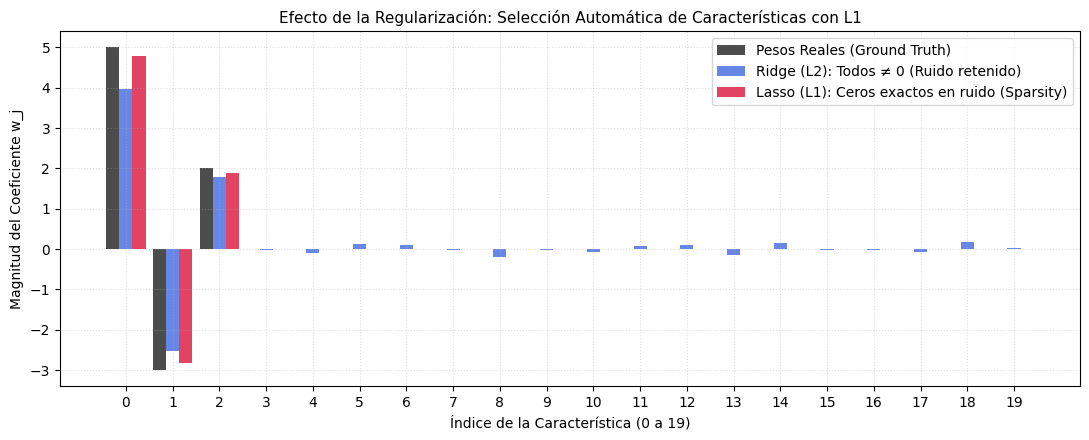

Variables anuladas a cero exacto por Ridge (L2): 0 de 20
Variables anuladas a cero exacto por Lasso (L1): 17 de 20 (¡Identificó las 17 columnas de ruido!)


In [5]:
# Generar datos sintéticos: 100 muestras, 20 características
np.random.seed(42)
m, d = 100, 20
X_sparse = np.random.randn(m, d)
# Solo las variables 0, 1, 2 tienen señal real
w_verdadero = np.zeros(d)
w_verdadero[0] = 5.0
w_verdadero[1] = -3.0
w_verdadero[2] = 2.0
y_sparse = X_sparse @ w_verdadero + np.random.randn(m) * 0.5

# Entrenar Ridge y Lasso
ridge = RidgeRegressionFromScratch(alpha=20.0).fit(X_sparse, y_sparse)
lasso = LassoRegressionFromScratch(alpha=15.0).fit(X_sparse, y_sparse)

# Comparativa de coeficientes
fig, ax = plt.subplots(figsize=(11, 4.5))
indices = np.arange(d)
width = 0.28

ax.bar(indices - width, w_verdadero, width, label="Pesos Reales (Ground Truth)", color="black", alpha=0.7)
ax.bar(indices, ridge.weights, width, label="Ridge (L2): Todos ≠ 0 (Ruido retenido)", color="royalblue", alpha=0.8)
ax.bar(indices + width, lasso.weights, width, label="Lasso (L1): Ceros exactos en ruido (Sparsity)", color="crimson", alpha=0.8)

ax.set_title("Efecto de la Regularización: Selección Automática de Características con L1", fontsize=11)
ax.set_xlabel("Índice de la Característica (0 a 19)")
ax.set_ylabel("Magnitud del Coeficiente w_j")
ax.set_xticks(indices)
ax.grid(True, linestyle=":", alpha=0.4)
ax.legend()
plt.tight_layout()
plt.show()

num_ceros_ridge = np.sum(np.isclose(ridge.weights, 0.0, atol=1e-5))
num_ceros_lasso = np.sum(np.isclose(lasso.weights, 0.0, atol=1e-5))
print(f"Variables anuladas a cero exacto por Ridge (L2): {num_ceros_ridge} de 20")
print(f"Variables anuladas a cero exacto por Lasso (L1): {num_ceros_lasso} de 20 (¡Identificó las 17 columnas de ruido!)")

---

## 4. ⚡ Transición a PyTorch Moderno

En PyTorch, la regularización $L_2$ no suele calcularse sumando $\lambda \sum w^2$ a la función de pérdida manualmente; está integrada directamente en el optimizador mediante el argumento **`weight_decay`**.

In [6]:
# Comparativa en PyTorch: Sin regularización vs Con Weight Decay
X_t = torch.from_numpy(X_sparse.astype(np.float32))
y_t = torch.from_numpy(y_sparse.astype(np.float32)).unsqueeze(1)

# 1. Modelo sobreajustado sin regularización
model_no_reg = nn.Linear(20, 1, bias=False)
opt_no_reg = torch.optim.SGD(model_no_reg.parameters(), lr=0.05, weight_decay=0.0)

# 2. Modelo con regularización L2 (Weight Decay)
model_decay = nn.Linear(20, 1, bias=False)
opt_decay = torch.optim.SGD(model_decay.parameters(), lr=0.05, weight_decay=0.1)

criterion = nn.MSELoss()
for _ in range(100):
    # Paso sin regularización
    opt_no_reg.zero_grad()
    loss1 = criterion(model_no_reg(X_t), y_t)
    loss1.backward()
    opt_no_reg.step()
    
    # Paso con weight decay
    opt_decay.zero_grad()
    loss2 = criterion(model_decay(X_t), y_t)
    loss2.backward()
    opt_decay.step()

norma_sin_reg = torch.norm(model_no_reg.weight).item()
norma_con_decay = torch.norm(model_decay.weight).item()
print(f"Norma L2 de pesos SIN regularización: {norma_sin_reg:.4f}")
print(f"Norma L2 de pesos CON Weight Decay:   {norma_con_decay:.4f}")
print(f"⚡ Contracción de la norma de pesos:   {norma_sin_reg / norma_con_decay:.2f}x menor")

Norma L2 de pesos SIN regularización: 6.0710
Norma L2 de pesos CON Weight Decay:   5.7743
⚡ Contracción de la norma de pesos:   1.05x menor


---

## 5. 🎯 Retos & Experimentos ("Tinker Time")

### Reto 1: Trazar el "Regularization Path" (Camino de Regularización)
El camino de regularización muestra la trayectoria continua de cada uno de los coeficientes $w_j$ conforme aumentamos $\lambda$ desde valores diminutos ($10^{-2}$) hasta valores gigantes ($10^3$):
* Observa a qué valor de $\lambda$ cada una de las 17 variables de ruido cruza a cero en Lasso.

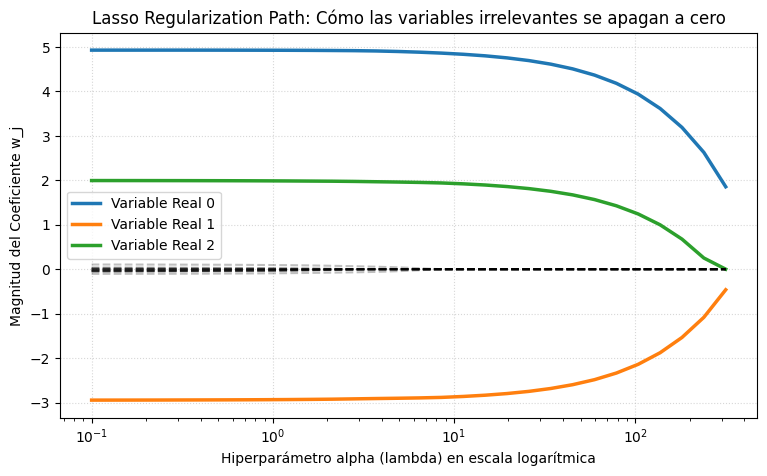

In [7]:
alphas = np.logspace(-1, 2.5, 30)
coeficientes_lasso = []

for a in alphas:
    modelo = LassoRegressionFromScratch(alpha=a, max_iter=500).fit(X_sparse, y_sparse)
    coeficientes_lasso.append(modelo.weights.copy())
coeficientes_lasso = np.array(coeficientes_lasso)

plt.figure(figsize=(9, 5))
for j in range(d):
    if j < 3:
        plt.plot(alphas, coeficientes_lasso[:, j], linewidth=2.5, label=f'Variable Real {j}')
    else:
        plt.plot(alphas, coeficientes_lasso[:, j], 'k--', alpha=0.25)
        
plt.xscale('log')
plt.xlabel('Hiperparámetro alpha (lambda) en escala logarítmica')
plt.ylabel('Magnitud del Coeficiente w_j')
plt.title('Lasso Regularization Path: Cómo las variables irrelevantes se apagan a cero')
plt.grid(True, linestyle=':', alpha=0.5)
plt.legend()
plt.show()

### Reto 2 (Para resolver): Implementar ElasticNet
En 2005, Hui Zou y Trevor Hastie descubrieron que cuando varias variables relevantes están fuertemente correlacionadas entre sí, Lasso tiende a seleccionar una al azar y apagar las demás.

Para resolver esto, crearon **ElasticNet**, combinando ambas normas:
$$\mathcal{L}_{ElasticNet}(w) = \mathcal{L}_{MSE}(w) + \lambda_1 \|w\|_1 + \frac{\lambda_2}{2} \|w\|_2^2$$

Su actualización en Coordinate Descent tiene la forma cerrada:
$$w_j = \frac{S(\rho_j, \lambda_1)}{z_j + \lambda_2}$$

Implementa a continuación el operador de ElasticNet:

In [8]:
# TU CÓDIGO DEL RETO 2 AQUÍ
def elastic_net_update(rho_j: float, z_j: float, lambda_1: float, lambda_2: float) -> float:
    """
    Calcula la actualización de coordenada para ElasticNet combinando L1 y L2.
    """
    # 1. Aplicar soft thresholding con lambda_1
    # 2. Dividir entre (z_j + lambda_2)
    pass

---

## 6. 📚 Referencias Fundamentales & Lecturas Recomendadas

### 📄 Papers Seminales
1. **Hoerl, A. E., & Kennard, R. W. (1970):** *"Ridge Regression: Biased Estimation for Nonorthogonal Problems"*, Technometrics, 12(1), 55-67. [JSTOR Link](https://www.jstor.org/stable/1267351)
   * *¿Qué leer?* La formulación de la curvatura del elipsoide y cómo $\lambda$ desplaza los valores propios lejos de cero.
2. **Tibshirani, R. (1996):** *"Regression Shrinkage and Selection via the Lasso"*, Journal of the Royal Statistical Society: Series B, 58(1), 267-288. [JSTOR Link](https://www.jstor.org/stable/2346178)
   * *¿Qué leer?* Sección 2 ("The Lasso Method") y la Figura 2 (la comparación geométrica entre las regiones $L_1$ y $L_2$).
3. **Zou, H., & Hastie, T. (2005):** *"Regularization and variable selection via the elastic net"*, Journal of the Royal Statistical Society: Series B, 67(2), 301-320.
   * *¿Qué leer?* El teorema del "Grouping Effect": por qué ElasticNet selecciona juntas variables correlacionadas en lugar de descartarlas.
4. **Loshchilov, I., & Hutter, F. (2019):** *"Decoupled Weight Decay Regularization (AdamW)"*, ICLR 2019. [arXiv Link](https://arxiv.org/abs/1711.05101)
   * *¿Qué leer?* Sección 2: La diferencia crucial entre regularización $L_2$ clásica y Weight Decay en optimizadores basados en momentos adaptativos como Adam.